# AdaBoost Classifier

# EDA

### Libraries

In [1]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, StandardScaler, MinMaxScaler
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import TomekLinks
from imblearn.combine import SMOTETomek
from sklearn.model_selection import train_test_split
from sklearn.ensemble import AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

In [2]:
df = pd.read_csv("Huntington_Disease_Dataset.csv")

In [3]:
df.shape

(48536, 21)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 48536 entries, 0 to 48535
Data columns (total 21 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Patient_ID                 48536 non-null  object 
 1   Age                        48536 non-null  int64  
 2   Sex                        48536 non-null  object 
 3   Family_History             48536 non-null  object 
 4   HTT_CAG_Repeat_Length      48536 non-null  int64  
 5   Motor_Symptoms             48536 non-null  object 
 6   Cognitive_Decline          36417 non-null  object 
 7   Chorea_Score               48536 non-null  float64
 8   Brain_Volume_Loss          48536 non-null  float64
 9   Functional_Capacity        48536 non-null  int64  
 10  Gene_Mutation_Type         48536 non-null  object 
 11  HTT_Gene_Expression_Level  48536 non-null  float64
 12  Protein_Aggregation_Level  48536 non-null  float64
 13  Random_Protein_Sequence    48536 non-null  obj

In [5]:
df.columns

Index(['Patient_ID', 'Age', 'Sex', 'Family_History', 'HTT_CAG_Repeat_Length',
       'Motor_Symptoms', 'Cognitive_Decline', 'Chorea_Score',
       'Brain_Volume_Loss', 'Functional_Capacity', 'Gene_Mutation_Type',
       'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level',
       'Random_Protein_Sequence', 'Random_Gene_Sequence', 'Disease_Stage',
       'Gene/Factor', 'Chromosome_Location', 'Function', 'Effect', 'Category'],
      dtype='object')

In [6]:
df.dtypes

Patient_ID                    object
Age                            int64
Sex                           object
Family_History                object
HTT_CAG_Repeat_Length          int64
Motor_Symptoms                object
Cognitive_Decline             object
Chorea_Score                 float64
Brain_Volume_Loss            float64
Functional_Capacity            int64
Gene_Mutation_Type            object
HTT_Gene_Expression_Level    float64
Protein_Aggregation_Level    float64
Random_Protein_Sequence       object
Random_Gene_Sequence          object
Disease_Stage                 object
Gene/Factor                   object
Chromosome_Location           object
Function                      object
Effect                        object
Category                      object
dtype: object

In [7]:
df.describe()

,Age,HTT_CAG_Repeat_Length,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,HTT_Gene_Expression_Level,Protein_Aggregation_Level
count,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000,48536.000000
mean,55.070566,57.516606,4.994399,5.261030,50.354829,1.301060,2.546519
std,14.762154,13.264153,2.897327,1.872995,29.189697,0.691657,1.414745
min,30.000000,35.000000,0.000000,2.000000,0.000000,0.100000,0.100000
25%,42.000000,46.000000,2.480000,3.640000,25.000000,0.700000,1.330000
50%,55.000000,58.000000,4.980000,5.280000,50.000000,1.300000,2.540000
75%,68.000000,69.000000,7.500000,6.880000,76.000000,1.900000,3.770000
max,80.000000,80.000000,10.000000,8.500000,100.000000,2.500000,5.000000


In [8]:
df.head()  

,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
0,b2a49170-8561-4665-9371-2240b55dd87a,31,Male,No,67,Moderate,Severe,8.80,3.20,94,...,1.67,0.58,DAHKIRSPMRVGPHYYAQCDNNDTGSDKEHWLKTEAAPMTMDRTVE...,GCCAGCAGCGCCCGAGCGTATGAGGTATATGGATTGGACATTGGGC...,Middle,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
1,f5fae45d-8718-41c4-a957-6928f79f3c8e,33,Female,Yes,38,Severe,Moderate,3.24,5.98,50,...,0.18,0.30,PANGFWYHNCLRFWNIPPYVMEGFPLADITEVHKWRVSGFMCWETQ...,AGTTTTCAGTGAGACTCTTCCCCAAAAGCCTCCACTACGACAGTGT...,Pre-Symptomatic,HTT,4p16.3,CAG Trinucleotide Repeat Expansion,Neurodegeneration,Primary Cause
2,66ab0567-050b-4d56-9ec4-b676309899a6,69,Male,Yes,37,Severe,Moderate,1.01,2.82,69,...,0.90,1.04,NWHEGHGASTWKATMVAWCLMVQHAVTWKEGNTRCREMSCMNFTQL...,TATACCACCAGTGGGAAGAGTAACGATTTTGGAGCGCCCCGAGTCC...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
3,996a48e4-e841-418f-a539-5a7a86cd815d,66,Male,Yes,50,Mild,Severe,3.21,6.77,76,...,1.16,1.87,KCVQYIQATQMLVQSWGQRNPIMQSSEPDRAHDYESGTPKTYTYML...,GCGCGACCGACCAAAGGACCCATGGTGGTGATCTGTCATTGGATTC...,Pre-Symptomatic,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
4,d45c7ca8-7125-4aaa-8018-5bbc60d35a1f,43,Female,Yes,48,Moderate,Mild,2.31,7.53,70,...,1.85,2.94,DQPGNMTRQNKNHCMWRAKRPTKHPGHKPGEIDKEKSEQNDADSSA...,GGGACCGCGGTTCTAGAAGAGAGGTTCTCTGACCGCCGAAGGATTC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


In [9]:
df.tail() 

,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,HTT_Gene_Expression_Level,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category
48531,27f82b73-b9fe-49d6-b6b9-82e667054725,78,Female,Yes,38,Moderate,Severe,0.09,4.71,89,...,0.49,1.24,WGYQYSFEMVIQWMYHSYMPQGGLGCHNENHYCFWQDHKVATAVTC...,CAATGACGCACCCTCGTAAGGGCTAGGCAGCGCCAGCCCACTTAAA...,Early,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48532,ff5af7cc-8132-4791-8e8b-aac71f2bade1,61,Female,Yes,76,Mild,NaN,8.80,6.92,78,...,2.44,3.34,TNVLFHILGLVENNMGQKFHQKAFPWCDTLMTSNWNGCAEGGNGEQ...,ACAAGAACAGTGGAACGGTTGAGTCACGGATGAGGCCTAGCGAGGT...,Middle,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
48533,f594aab8-7acf-43cd-95d8-c197e202c4ea,66,Male,No,35,Severe,Severe,2.73,6.61,24,...,0.51,0.27,NRWNVDINSRMMHFYYFHTSPRSVTPWTPKQEREVYKQMFQKYAQS...,GGTATATCGTTAGGGCCGTCGGTGAACACTTCTAATCTAGGCTTAA...,Middle,MSH3,5q14.1,Mismatch Repair,CAG Repeat Expansion,Trans-acting Modifier
48534,32052e20-c2ae-4314-95ce-5daf720b26ca,37,Female,Yes,80,Mild,NaN,9.81,2.95,19,...,1.16,3.22,AKDHQGVPWLPRITQKQTVQQQPIKWMHWVPENARGTIIREFFAYA...,GGTTTTCGTTCTCGTAGTATCAACAGAGGGGAATTTTATTACTGGC...,Late,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier
48535,b063b8fb-9e12-40c2-b6bb-da675033dfd2,37,Female,Yes,48,Severe,NaN,0.26,5.25,50,...,1.70,4.59,WTRLKMNYRQFKRERKYEGQEAIAPSEKGKDNAFPTMEIGIWCNES...,ACCGGCGGAGACCGCCGATGTAGTGGTCCTCACTGACCATCTCGCA...,Early,HTT (Somatic Expansion),4p16.3,CAG Repeat Instability,Faster Disease Onset,Cis-acting Modifier


### ADDITIONAL EDA 

### Numerical and Categorical separtion of Columns

In [10]:
numeric_cols = df.select_dtypes(include=['int64','float64']).columns.tolist()
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()

remove_cols = [
    'Patient_ID',
    'Category',
    'Random_Protein_Sequence',
    'Random_Gene_Sequence'
]

categorical_cols = [col for col in categorical_cols if col not in remove_cols]

print("Numeric Columns:", numeric_cols)
print("Categorical Columns:", categorical_cols)


Numeric Columns: ['Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score', 'Brain_Volume_Loss', 'Functional_Capacity', 'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level']
Categorical Columns: ['Sex', 'Family_History', 'Motor_Symptoms', 'Cognitive_Decline', 'Gene_Mutation_Type', 'Disease_Stage', 'Gene/Factor', 'Chromosome_Location', 'Function', 'Effect']


### Correlation of each feature directly with category

In [54]:

df['Category'] = df['Category'].astype(int)

print("Correlation of numeric features with Category:")

for col in df.columns:
    if df[col].dtype != 'object' and col != 'Category': 
        corr = df[col].corr(df['Category'])
        print(f"{col}: correlation with Category = {corr:.2f}")


Correlation of numeric features with Category:
Patient_ID: correlation with Category = -0.01
Age: correlation with Category = 0.00
Sex: correlation with Category = 0.00
Family_History: correlation with Category = -0.00
HTT_CAG_Repeat_Length: correlation with Category = 0.00
Motor_Symptoms: correlation with Category = -0.00
Cognitive_Decline: correlation with Category = -0.00
Chorea_Score: correlation with Category = -0.01
Brain_Volume_Loss: correlation with Category = 0.00
Functional_Capacity: correlation with Category = -0.00
Gene_Mutation_Type: correlation with Category = 0.00
HTT_Gene_Expression_Level: correlation with Category = -0.01
Protein_Aggregation_Level: correlation with Category = -0.00
Random_Protein_Sequence: correlation with Category = -0.00
Random_Gene_Sequence: correlation with Category = -0.00
Disease_Stage: correlation with Category = 0.00
Gene/Factor: correlation with Category = 0.67
Chromosome_Location: correlation with Category = -0.01
Function: correlation with C

In [12]:
df['Category'].value_counts()


Category
Trans-acting Modifier    24279
Primary Cause            12229
Cis-acting Modifier      12028
Name: count, dtype: int64

### UNIQUE,DUPLICATED AND NULL VALUES

In [13]:
df.nunique()

Patient_ID                   48536
Age                             51
Sex                              2
Family_History                   2
HTT_CAG_Repeat_Length           46
Motor_Symptoms                   3
Cognitive_Decline                3
Chorea_Score                  1001
Brain_Volume_Loss              651
Functional_Capacity            101
Gene_Mutation_Type               4
HTT_Gene_Expression_Level      241
Protein_Aggregation_Level      491
Random_Protein_Sequence      48536
Random_Gene_Sequence         48536
Disease_Stage                    4
Gene/Factor                      4
Chromosome_Location              3
Function                         3
Effect                           3
Category                         3
dtype: int64

In [14]:
print(df.duplicated())

0        False
1        False
2        False
3        False
4        False
         ...  
48531    False
48532    False
48533    False
48534    False
48535    False
Length: 48536, dtype: bool


In [15]:
print(f"DUPLICATES: {df.duplicated().sum()}")


DUPLICATES: 0


In [16]:
df=df.drop_duplicates()

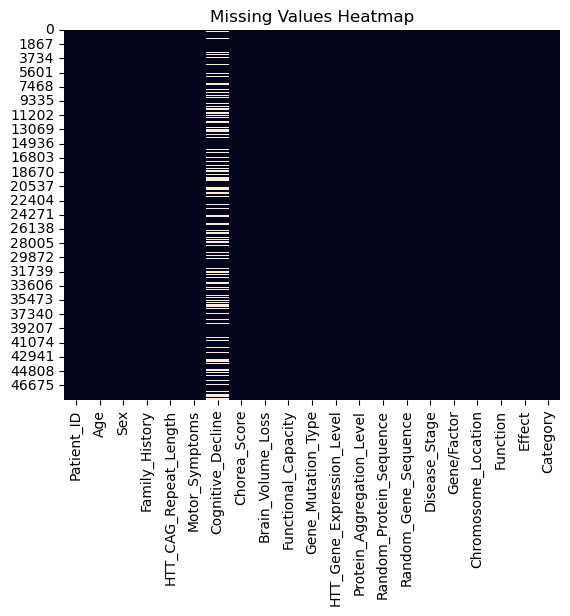

In [17]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()


In [18]:
df.isnull().sum() 

Patient_ID                       0
Age                              0
Sex                              0
Family_History                   0
HTT_CAG_Repeat_Length            0
Motor_Symptoms                   0
Cognitive_Decline            12119
Chorea_Score                     0
Brain_Volume_Loss                0
Functional_Capacity              0
Gene_Mutation_Type               0
HTT_Gene_Expression_Level        0
Protein_Aggregation_Level        0
Random_Protein_Sequence          0
Random_Gene_Sequence             0
Disease_Stage                    0
Gene/Factor                      0
Chromosome_Location              0
Function                         0
Effect                           0
Category                         0
dtype: int64

In [19]:
df.dropna(how='any',inplace=True)
df.dropna(how='all',inplace=True)

In [20]:
for col in df.columns:
    if df[col].dtype=='object':
        df[col]=df[col].fillna(df[col].mode()[0])
    else:
        df[col]=df[col].fillna(df[col].median()) 


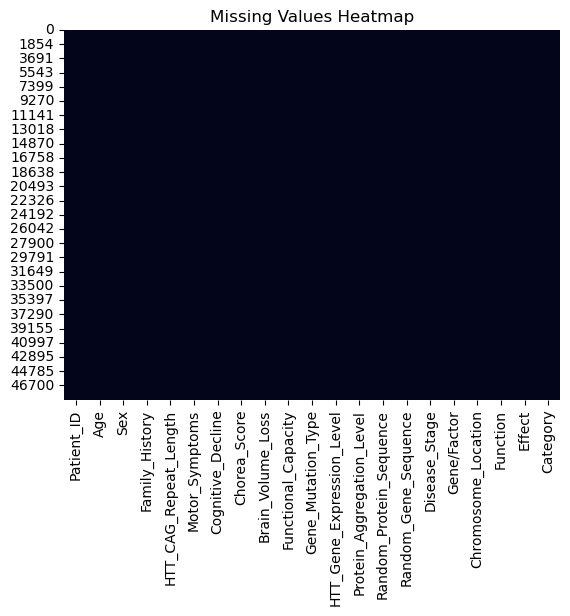

In [21]:
sns.heatmap(df.isnull(), cbar=False)
plt.title('Missing Values Heatmap')
plt.show()


# VISUALIZATIONS

### Countplot

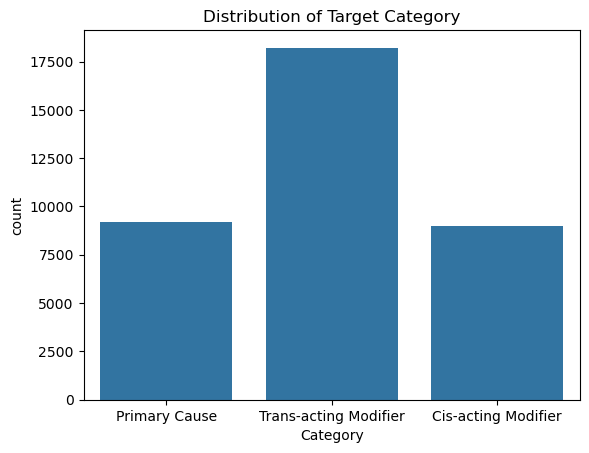

Category
Trans-acting Modifier    18213
Primary Cause             9209
Cis-acting Modifier       8995
Name: count, dtype: int64


In [22]:
sns.countplot(x='Category', data=df)
plt.title('Distribution of Target Category')
plt.show()

print(df['Category'].value_counts())

### Histograms

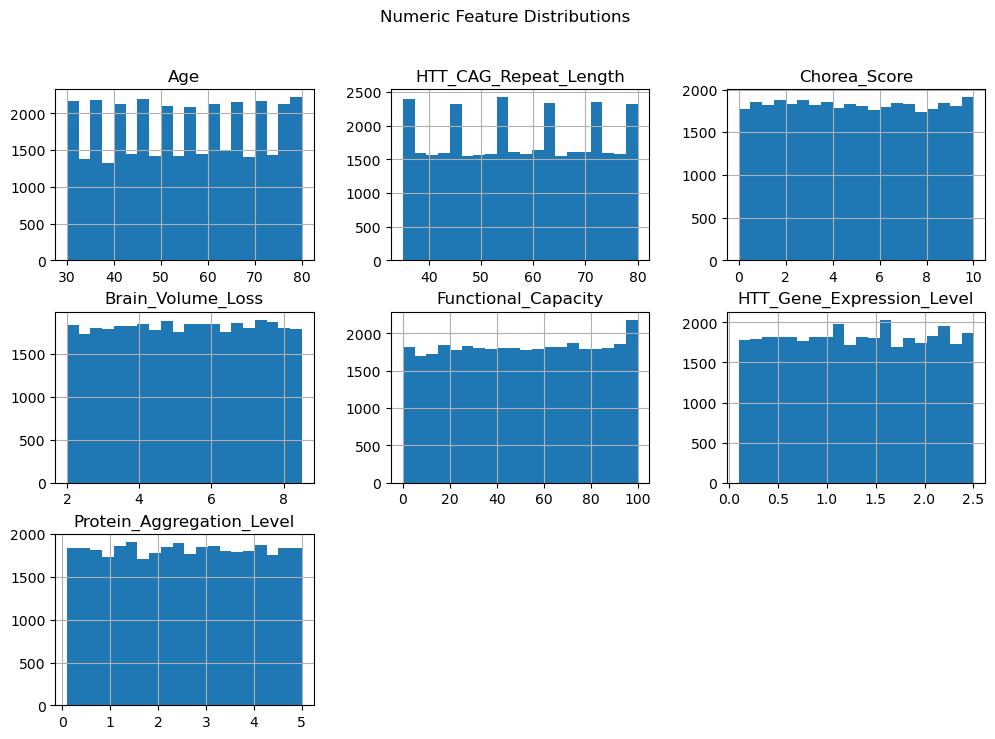

In [23]:
numeric_cols = ['Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score',
                'Brain_Volume_Loss', 'Functional_Capacity',
                'HTT_Gene_Expression_Level', 'Protein_Aggregation_Level']

df[numeric_cols].hist(figsize=(12,8), bins=20)
plt.suptitle('Numeric Feature Distributions')
plt.show()


### Boxplot

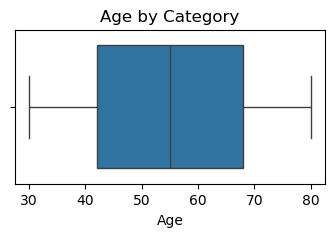

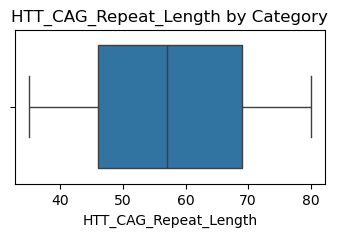

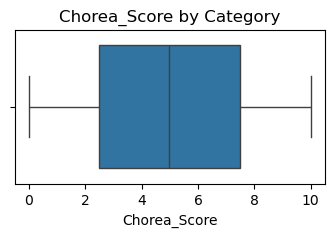

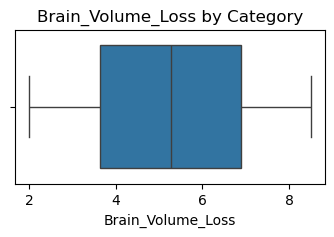

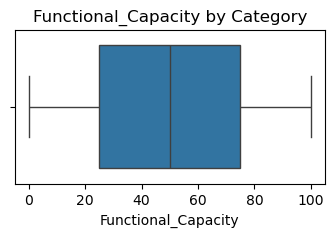

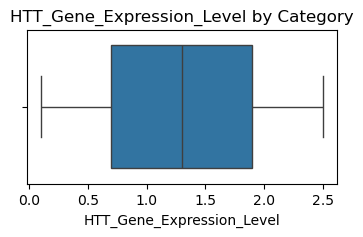

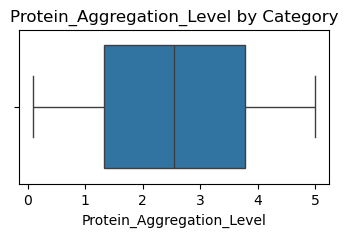

In [24]:
for col in numeric_cols:
    plt.figure(figsize=(4,2))
    sns.boxplot(x=df[col])
    plt.title(f'{col} by Category')
    plt.show()



### Scatterplot

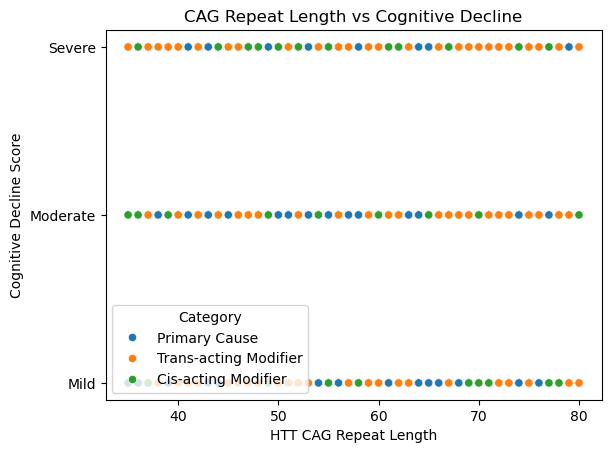

In [25]:
sns.scatterplot(
    x='HTT_CAG_Repeat_Length',
    y='Cognitive_Decline',
    hue='Category',    # optional
    data=df
)
plt.title('CAG Repeat Length vs Cognitive Decline')
plt.xlabel('HTT CAG Repeat Length')
plt.ylabel('Cognitive Decline Score')
plt.show()

### Heatmap

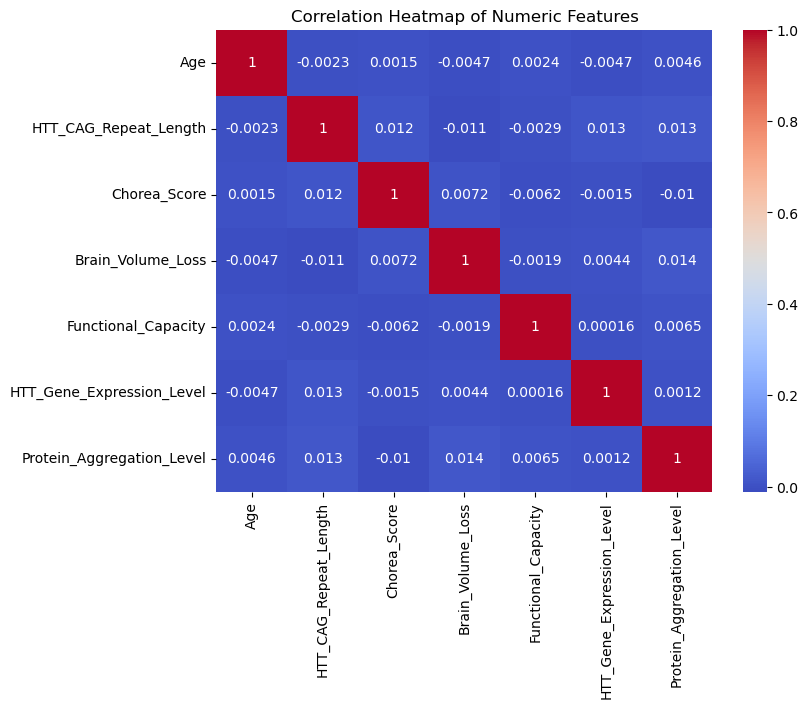

In [26]:
corr = df[numeric_cols].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap of Numeric Features')
plt.show()


### Violinplot

C:\Users\minah\AppData\Local\Temp\ipykernel_16172\2698626216.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Category', y='Brain_Volume_Loss', data=df, palette='pastel')


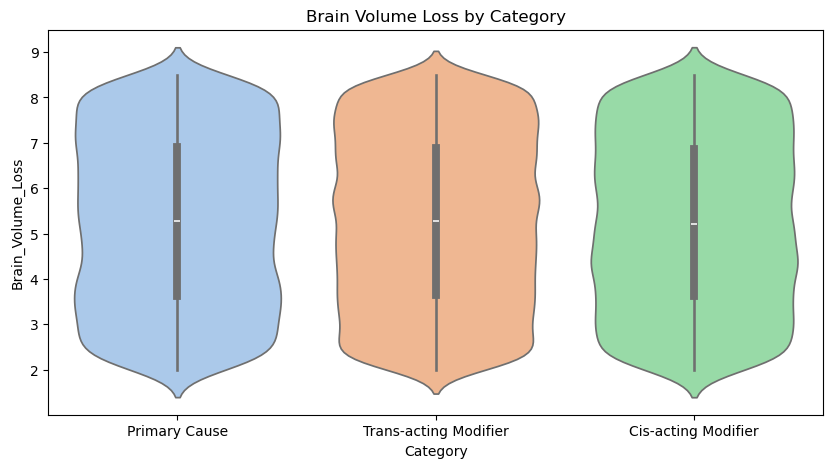

In [30]:
plt.figure(figsize=(10,5))
sns.violinplot(x='Category', y='Brain_Volume_Loss', data=df, palette='pastel')
plt.title('Brain Volume Loss by Category')
plt.show()



### Countplot per feature

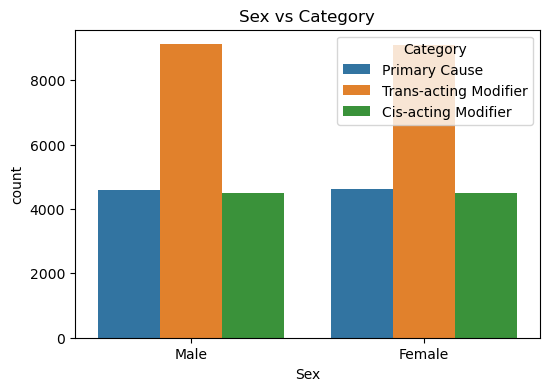

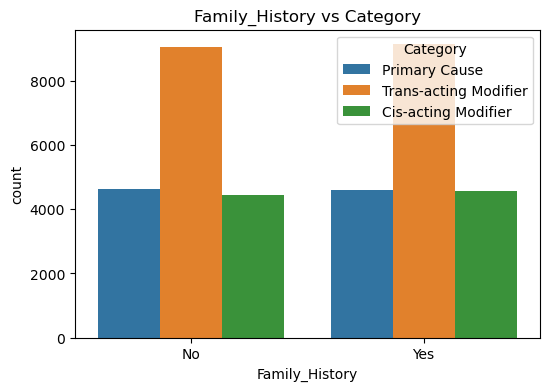

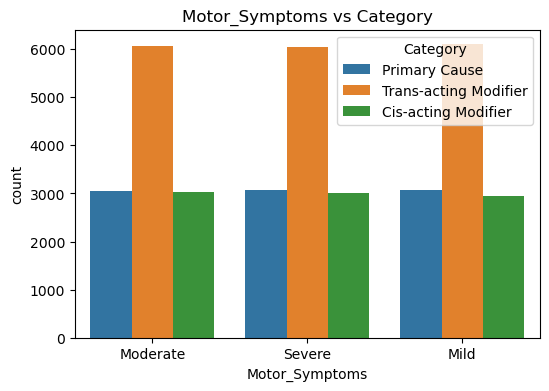

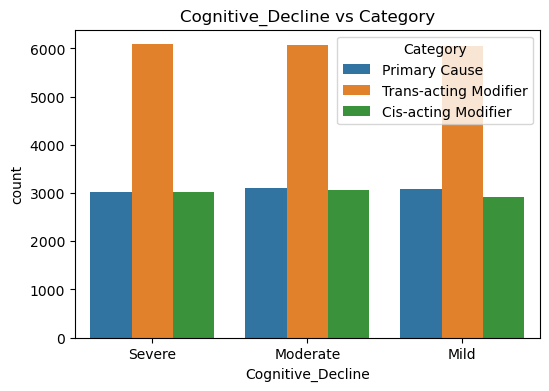

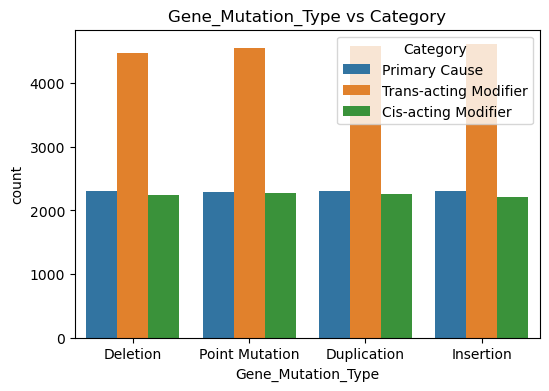

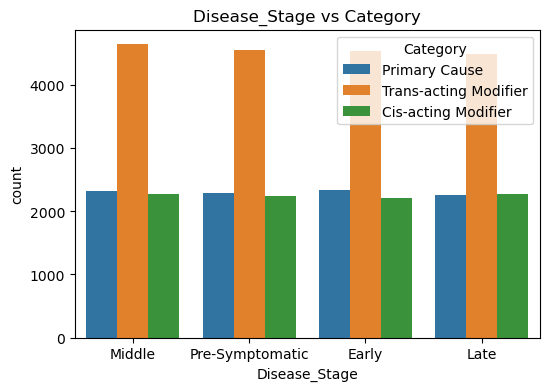

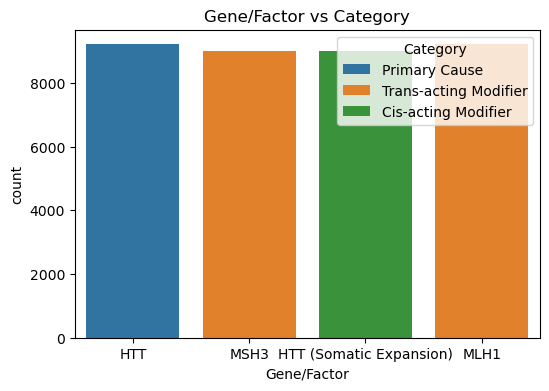

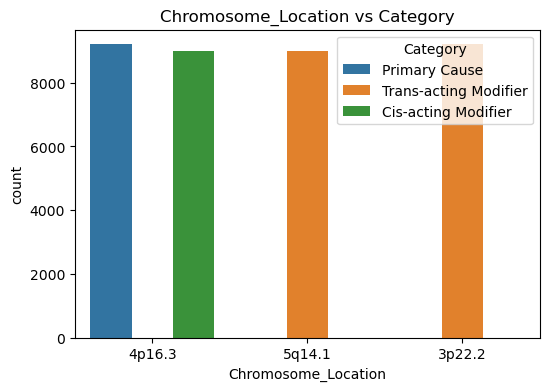

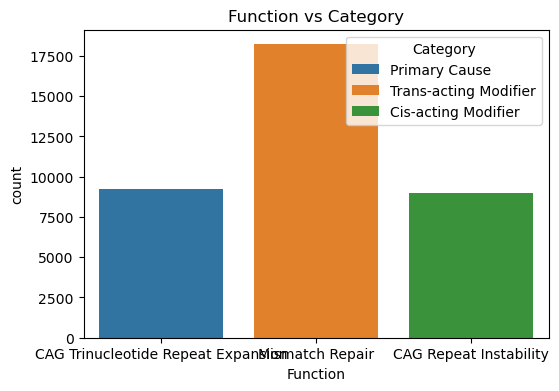

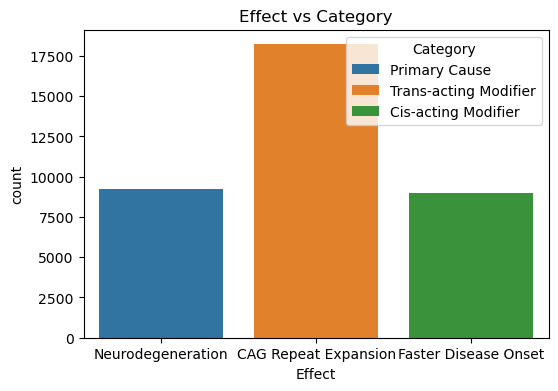

In [31]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(x=col, hue='Category', data=df)
    plt.title(f'{col} vs Category')
    plt.show()


### Pie chart per category

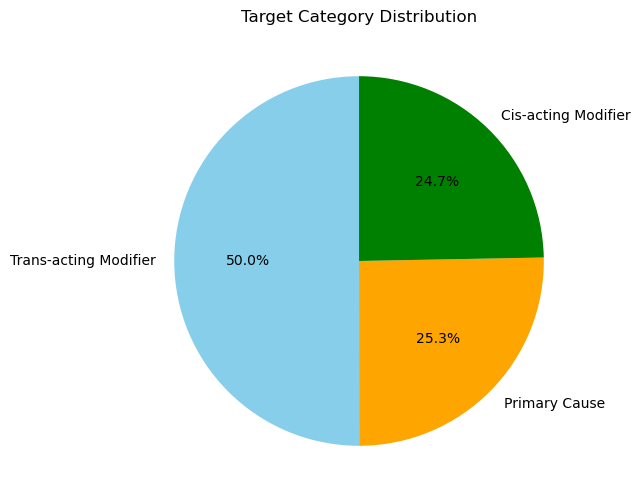

In [32]:

category_counts = df['Category'].value_counts()
plt.figure(figsize=(6,6))
plt.pie(category_counts, labels=category_counts.index, autopct='%1.1f%%', startangle=90, colors=['skyblue','orange','green'])
plt.title('Target Category Distribution')
plt.show()




### KDE plot

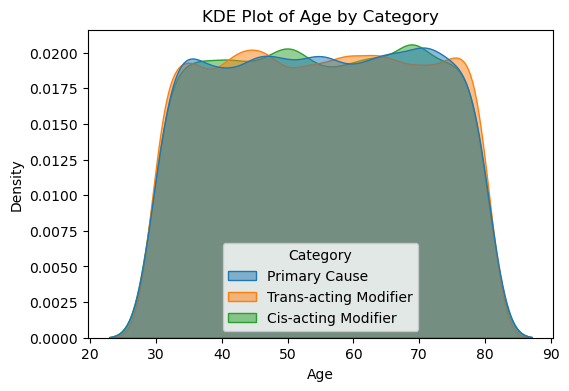

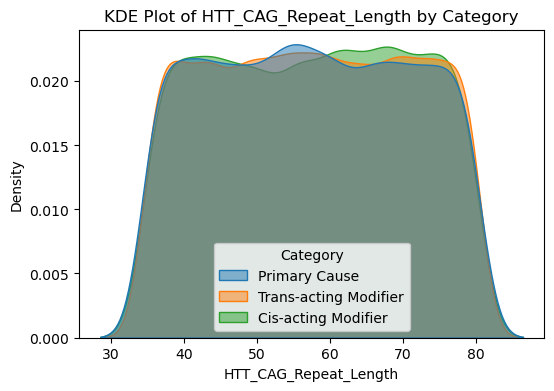

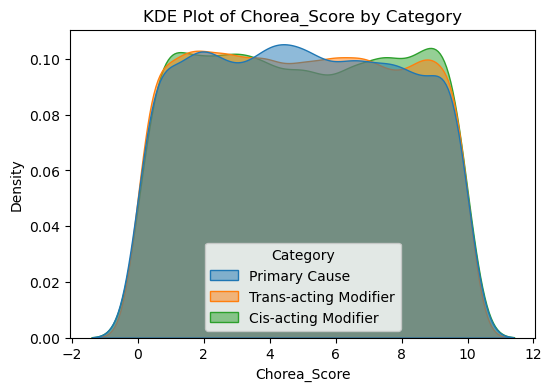

In [33]:

numeric_cols = ['Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score']
for col in numeric_cols:
    plt.figure(figsize=(6,4))
    sns.kdeplot(data=df, x=col, hue='Category', fill=True, common_norm=False, alpha=0.5)
    plt.title(f'KDE Plot of {col} by Category')
    plt.show()


### 3D scatter plot

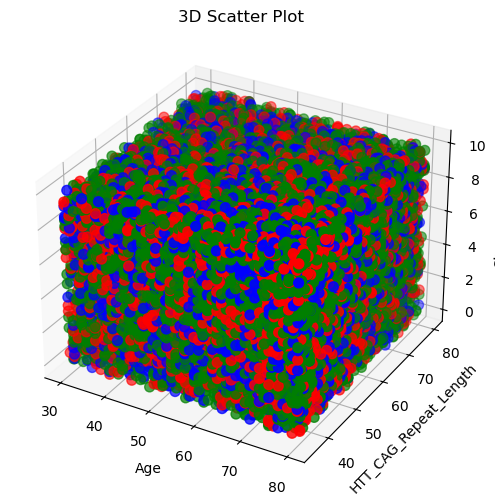

In [34]:


fig = plt.figure(figsize=(8,6))
ax = fig.add_subplot(111, projection='3d')
x = df['Age']
y = df['HTT_CAG_Repeat_Length']
z = df['Chorea_Score']
classes = df['Category']
colors = ['r','g','b']
class_dict = {cls:colors[i] for i, cls in enumerate(df['Category'].unique())}
ax.scatter(x, y, z, c=[class_dict[c] for c in classes], s=50)

ax.set_xlabel('Age')
ax.set_ylabel('HTT_CAG_Repeat_Length')
ax.set_zlabel('Chorea_Score')
plt.title('3D Scatter Plot')
plt.show()


### Density plot

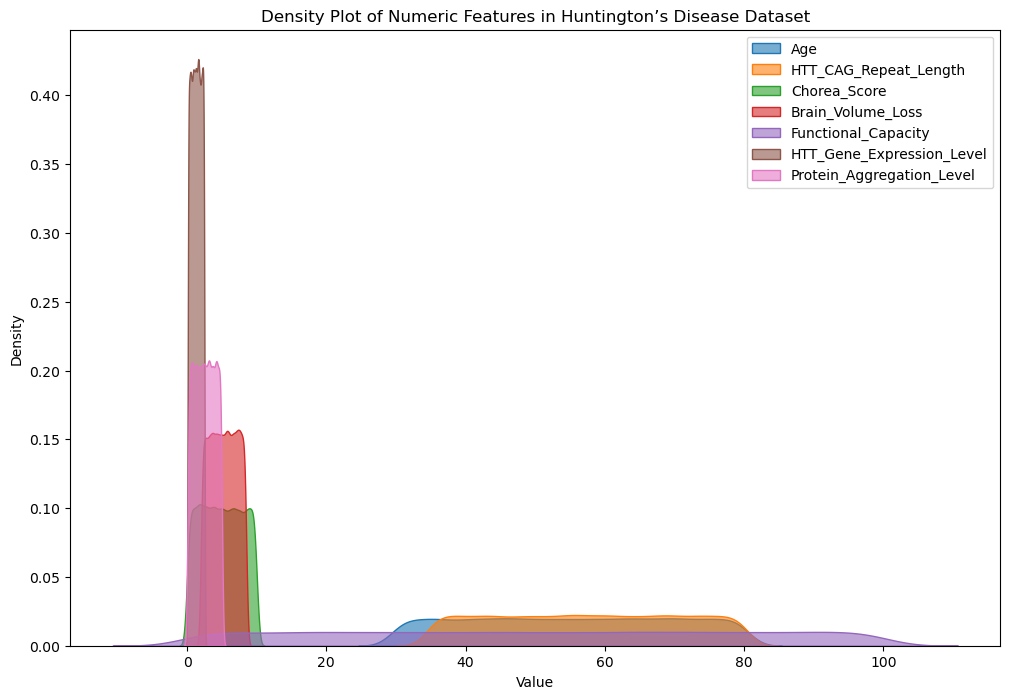

In [35]:

numeric_cols = [
    'Age', 
    'HTT_CAG_Repeat_Length', 
    'Chorea_Score', 
    'Brain_Volume_Loss', 
    'Functional_Capacity', 
    'HTT_Gene_Expression_Level', 
    'Protein_Aggregation_Level'
]

plt.figure(figsize=(12,8))

for col in numeric_cols:
    sns.kdeplot(df[col], fill=True, label=col, alpha=0.6)

plt.title('Density Plot of Numeric Features in Huntington’s Disease Dataset')
plt.xlabel('Value')
plt.ylabel('Density')
plt.legend()
plt.show()


### Strip plot

AttributeError: module 'matplotlib.pyplot' has no attribute 'legend_'

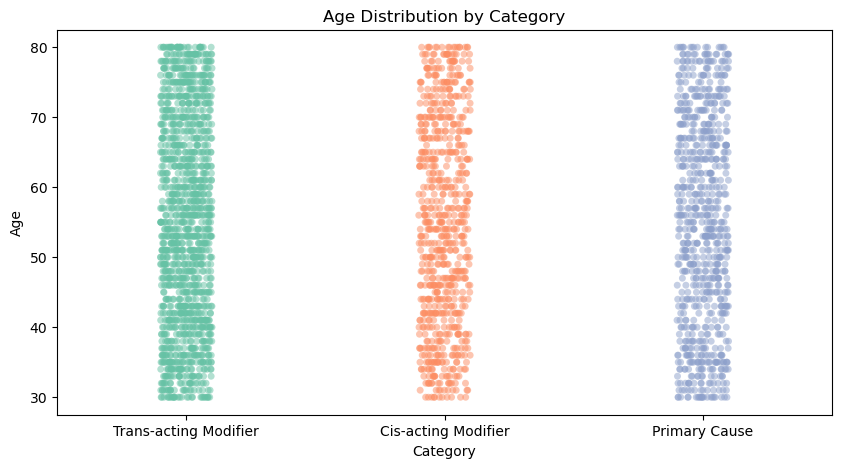

In [36]:

numeric_cols = ['Age', 'HTT_CAG_Repeat_Length', 'Chorea_Score',
                'Brain_Volume_Loss', 'Functional_Capacity']

df_sample = df.sample(n=3000, random_state=42) 

for col in numeric_cols:
    plt.figure(figsize=(10,5))
    sns.stripplot(
        x='Category',
        y=col,
        data=df_sample,
        hue='Category',
        palette='Set2',
        dodge=False,
        alpha=0.5
    )
    plt.title(f'{col} Distribution by Category')
    plt.legend_.remove()
    plt.show()


### Scatter plot

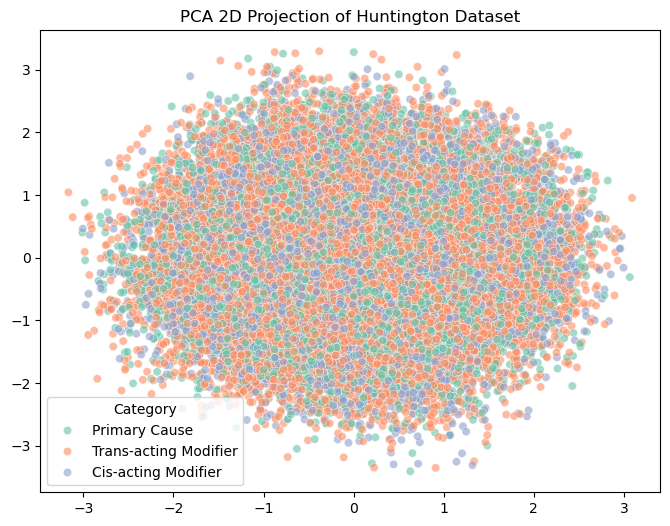

In [37]:
from sklearn.decomposition import PCA
numeric_cols = df.select_dtypes(include='number').columns.tolist()
X = df[numeric_cols].drop(columns=['Patient_ID'], errors='ignore')
X_scaled = StandardScaler().fit_transform(X)

pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

plt.figure(figsize=(8,6))
sns.scatterplot(
    x=X_pca[:,0],
    y=X_pca[:,1],
    hue=df['Category'],
    palette='Set2',
    alpha=0.6
)
plt.title('PCA 2D Projection of Huntington Dataset')
plt.show()


# Label Encoding

In [38]:
categorical_cols= df.select_dtypes(include="object").columns
df['Age_Group']=LabelEncoder().fit_transform(df[col])
for col in categorical_cols:
    df[col]=LabelEncoder().fit_transform(df[col]) 
df.tail()


,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category,Age_Group
48528,4892,52,0,1,65,2,0,6.85,5.31,33,...,3.34,3710,24236,3,0,1,1,2,1,22
48529,25414,65,1,1,74,0,2,5.31,6.75,59,...,4.56,13260,21132,1,1,1,0,1,0,35
48530,10400,46,0,1,44,1,0,2.26,3.55,89,...,0.19,23320,25300,3,0,1,1,2,1,16
48531,5669,78,0,1,38,1,2,0.09,4.71,89,...,1.24,33222,9573,0,3,2,2,0,2,48
48533,34871,66,1,0,35,2,2,2.73,6.61,24,...,0.27,21231,24509,2,3,2,2,0,2,36


# Standard Scaling

In [39]:
columns_to_scale = [
    'Age',
    'HTT_CAG_Repeat_Length',
    'Chorea_Score',
    'Brain_Volume_Loss',
    'Functional_Capacity',
    'HTT_Gene_Expression_Level',
    'Protein_Aggregation_Level'
]
scalar = StandardScaler()
df[columns_to_scale]=scalar.fit_transform(df[columns_to_scale])
df.tail()




,Patient_ID,Age,Sex,Family_History,HTT_CAG_Repeat_Length,Motor_Symptoms,Cognitive_Decline,Chorea_Score,Brain_Volume_Loss,Functional_Capacity,...,Protein_Aggregation_Level,Random_Protein_Sequence,Random_Gene_Sequence,Disease_Stage,Gene/Factor,Chromosome_Location,Function,Effect,Category,Age_Group
48528,4892,-0.209120,0,1,0.566550,2,0,0.643704,0.026792,-0.593401,...,0.557696,3710,24236,3,0,1,1,2,1,22
48529,25414,0.672431,1,1,1.245048,0,2,0.111281,0.795553,0.298853,...,1.419559,13260,21132,1,1,1,0,1,0,35
48530,10400,-0.615990,0,1,-1.016611,1,0,-0.943192,-0.912805,1.328378,...,-1.667605,23320,25300,3,0,1,1,2,1,16
48531,5669,1.553983,0,1,-1.468943,1,2,-1.693423,-0.293525,1.328378,...,-0.925838,33222,9573,0,3,2,2,0,2,48
48533,34871,0.740243,1,0,-1.695109,2,2,-0.780699,0.720812,-0.902258,...,-1.611089,21231,24509,2,3,2,2,0,2,36


# AdaBoost Classifier

### TRAIN TEST SPLIT
Data Set is splitted into 60% trainnig and 40% testing data.  
The trainning data is resampled using SMOTE.  
The model is trained on resampled training data.   

In [40]:

print(df.corr()['Category'].sort_values(ascending=False))
print(df[['Function', 'Category']].corr())

Category                     1.000000
Function                     1.000000
Gene/Factor                  0.673320
Brain_Volume_Loss            0.004366
Gene_Mutation_Type           0.001985
Disease_Stage                0.001095
HTT_CAG_Repeat_Length        0.000771
Age                          0.000390
Age_Group                    0.000390
Sex                          0.000143
Protein_Aggregation_Level   -0.000607
Functional_Capacity         -0.002293
Family_History              -0.002965
Cognitive_Decline           -0.003580
Random_Protein_Sequence     -0.004059
Motor_Symptoms              -0.004641
Random_Gene_Sequence        -0.004970
Chorea_Score                -0.006066
HTT_Gene_Expression_Level   -0.006316
Chromosome_Location         -0.007053
Patient_ID                  -0.009644
Effect                      -0.636471
Name: Category, dtype: float64
          Function  Category
Function       1.0       1.0
Category       1.0       1.0


In [41]:

X = df.drop(columns=['Patient_ID', 'Category', 'Age_Group','Function','Gene/Factor','Effect'])
y = df['Category']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.4,
    stratify=y,
    random_state=42
)

smote = SMOTE(sampling_strategy='not majority', random_state=42, k_neighbors=5)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)


print("Original counts (full dataset):")
print(y.value_counts())

print("\nResampled training counts:")
print(pd.Series(y_train_res).value_counts())

print("\nTest set counts (unchanged):")
print(y_test.value_counts())


Original counts (full dataset):
Category
2    18213
1     9209
0     8995
Name: count, dtype: int64

Resampled training counts:
Category
2    10928
1    10928
0    10928
Name: count, dtype: int64

Test set counts (unchanged):
Category
2    7285
1    3684
0    3598
Name: count, dtype: int64


In [42]:

duplicates = pd.merge(X_train, X_test, how='inner')
print(f"Number of duplicate rows between train and test: {len(duplicates)}")




Number of duplicate rows between train and test: 0


### MODEL
100 weak models are working together to predict.  
Each model is being trained on a single feature.  
with a learning rate of 0.5.  


In [43]:
base_learner = DecisionTreeClassifier(
    max_depth=1,
    random_state=42
)
ada = AdaBoostClassifier(
    estimator=base_learner,
    n_estimators=150,
    learning_rate=0.5,
    random_state=42
)



### TRAIN

In [44]:
ada.fit(X_train, y_train)


AdaBoostClassifier(estimator=DecisionTreeClassifier(max_depth=1,
                                                    random_state=42),
                   learning_rate=0.5, n_estimators=150, random_state=42)

### TEST

In [45]:
y_pred = ada.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.33      1.00      0.49      3598
           1       0.00      0.00      0.00      3684
           2       1.00      0.49      0.66      7285

    accuracy                           0.49     14567
   macro avg       0.44      0.50      0.38     14567
weighted avg       0.58      0.49      0.45     14567



C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


# EVALUATION

### Confusion Matrix

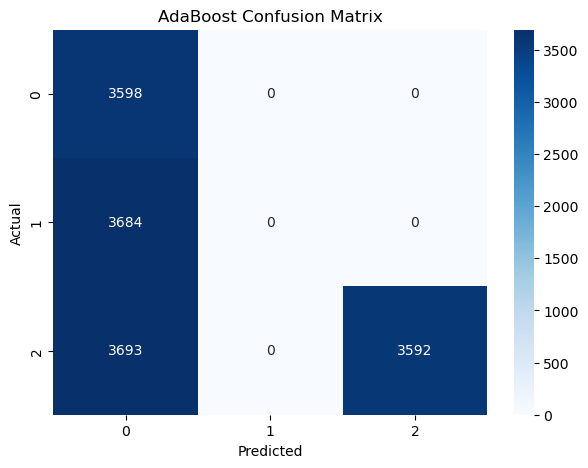

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred)

classes = sorted(y_test.unique())

plt.figure(figsize=(7,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=classes,
            yticklabels=classes)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("AdaBoost Confusion Matrix")
plt.show()


### Important Features

In [47]:
importances = ada.feature_importances_  
features = X_train_res.columns
imp_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)
print(imp_df.head(10))


                  Feature  Importance
15    Chromosome_Location         1.0
0                     Age         0.0
2          Family_History         0.0
1                     Sex         0.0
4          Motor_Symptoms         0.0
5       Cognitive_Decline         0.0
6            Chorea_Score         0.0
3   HTT_CAG_Repeat_Length         0.0
7       Brain_Volume_Loss         0.0
8     Functional_Capacity         0.0


C:\Users\minah\AppData\Local\Temp\ipykernel_16172\4177534276.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature' ,data=imp_df.head(10), palette='Set2')


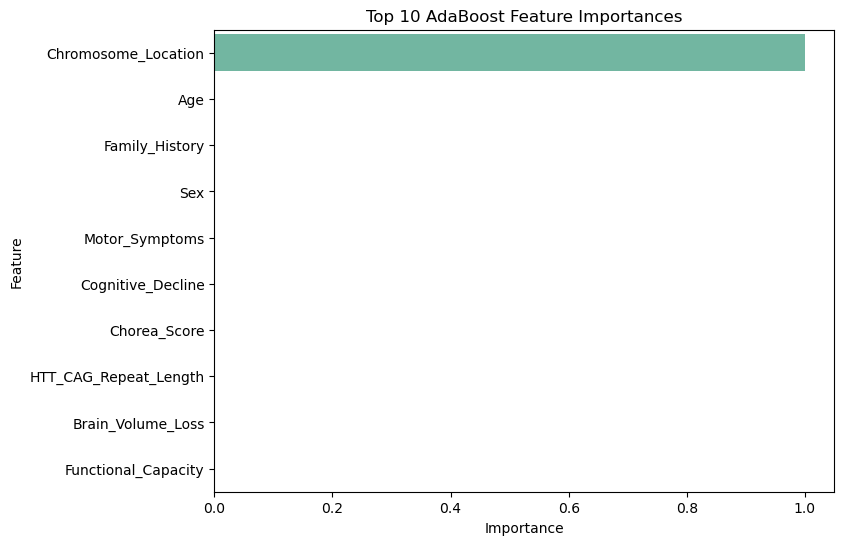

In [48]:
plt.figure(figsize=(8,6))
sns.barplot(x='Importance', y='Feature' ,data=imp_df.head(10), palette='Set2')
plt.title('Top 10 AdaBoost Feature Importances')
plt.show()


### Probabilities

In [49]:
num_samples = 10
sample_X = X_test.iloc[:num_samples]
sample_y = y_test.iloc[:num_samples]

pred_classes = ada.predict(sample_X)
pred_probs = ada.predict_proba(sample_X) if hasattr(ada, "predict_proba") else None

print(f"{'Index':<5} {'Actual':<15} {'Predicted':<15} {'Probabilities'}")
print("-"*80)
for i in range(num_samples):
    probs = np.round(pred_probs[i], 3) if pred_probs is not None else "N/A"
    print(f"{sample_X.index[i]:<5} {sample_y.iloc[i]:<15} {pred_classes[i]:<15} {probs}")


Index Actual          Predicted       Probabilities
--------------------------------------------------------------------------------
36904 1               0               [0.373 0.372 0.256]
6271  2               0               [0.373 0.256 0.372]
23654 1               0               [0.373 0.372 0.256]
39508 2               0               [0.373 0.256 0.372]
39175 1               0               [0.373 0.372 0.256]
11250 0               0               [0.373 0.372 0.256]
37166 2               2               [0.256 0.372 0.373]
18362 0               0               [0.373 0.372 0.256]
27318 2               0               [0.373 0.256 0.372]
10819 0               0               [0.373 0.372 0.256]


# User Input And Predictions

In [51]:
user_features = ['Age', 'Sex', 'Family_History']
user_input = X_train_res.sample(1).iloc[0].to_dict()

print("Please enter your information:")
for col in user_features:
    if col == 'Sex':
        value = input("Sex (Female/Male): ").strip().capitalize()
        while value not in ['Female', 'Male']:
            value = input("Invalid input. Please enter 'Female' or 'Male': ").strip().capitalize()
        user_input[col] = 0 if value == 'Female' else 1

    elif col == 'Family_History':
        value = input("Family History of disease? (Yes/No): ").strip().capitalize()
        while value not in ['Yes', 'No']:
            value = input("Invalid input. Please enter 'Yes' or 'No': ").strip().capitalize()
        user_input[col] = 1 if value == 'Yes' else 0

    else:
        value = input("Age (in years): ").strip()
        while not value.isdigit():
            value = input("Invalid input. Please enter a number for Age: ").strip()
        value = int(value)
        min_val = X_train_res['Age'].min()
        max_val = X_train_res['Age'].max()
        user_input[col] = np.clip(value, min_val, max_val)

user_df = pd.DataFrame([user_input])
pred_class = ada.predict(user_df)[0]
pred_probs = ada.predict_proba(user_df)[0] if hasattr(ada, "predict_proba") else None

print(f"\nPredicted Category: {pred_class}")
if pred_probs is not None:
    prob_dict = {cls: round(p, 3) for cls, p in zip(ada.classes_, pred_probs)}
    print(f"Prediction Probabilities: {prob_dict}")


Please enter your information:


Age (in years):  62
Sex (Female/Male):  Female
Family History of disease? (Yes/No):  Yes



Predicted Category: 0
Prediction Probabilities: {np.int64(0): np.float64(0.373), np.int64(1): np.float64(0.372), np.int64(2): np.float64(0.256)}


# HYPER TUNED AdaBoost Classifiers

In [52]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import AdaBoostClassifier
from sklearn.metrics import classification_report, accuracy_score

# Define different hyperparameter sets
hyperparams_list = [
    {'n_estimators': 250, 'learning_rate': 0.5, 'max_depth': 1},
    {'n_estimators': 100, 'learning_rate': 0.5, 'max_depth': 1},
    {'n_estimators': 150, 'learning_rate': 1.0, 'max_depth': 2},
]

results = []

for i, params in enumerate(hyperparams_list):
    # Base learner
    base = DecisionTreeClassifier(max_depth=params['max_depth'], random_state=42)
    
    # AdaBoost with current hyperparameters
    ada = AdaBoostClassifier(
        estimator=base,
        n_estimators=params['n_estimators'],
        learning_rate=params['learning_rate'],
        random_state=42
    )
    
    # Train
    ada.fit(X_train, y_train)
    
    # Predict
    y_pred = ada.predict(X_test)
    
    # Evaluate
    acc = accuracy_score(y_test, y_pred)
    results.append((params, acc))
    
    print(f"\nModel {i+1} with params {params}:")
    print(f"Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred))
    
# Combine / Compare results
print("\nSummary of all hyperparameter sets:")
for r in results:
    print(f"Params: {r[0]}, Accuracy: {r[1]:.4f}")



Model 1 with params {'n_estimators': 250, 'learning_rate': 0.5, 'max_depth': 1}:
Accuracy: 0.4936
              precision    recall  f1-score   support

           0       0.33      1.00      0.49      3598
           1       0.00      0.00      0.00      3684
           2       1.00      0.49      0.66      7285

    accuracy                           0.49     14567
   macro avg       0.44      0.50      0.38     14567
weighted avg       0.58      0.49      0.45     14567



C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model 2 with params {'n_estimators': 100, 'learning_rate': 0.5, 'max_depth': 1}:
Accuracy: 0.4936
              precision    recall  f1-score   support

           0       0.33      1.00      0.49      3598
           1       0.00      0.00      0.00      3684
           2       1.00      0.49      0.66      7285

    accuracy                           0.49     14567
   macro avg       0.44      0.50      0.38     14567
weighted avg       0.58      0.49      0.45     14567



C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\minah\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))



Model 3 with params {'n_estimators': 150, 'learning_rate': 1.0, 'max_depth': 2}:
Accuracy: 0.7470
              precision    recall  f1-score   support

           0       0.49      1.00      0.66      3598
           1       0.43      0.00      0.00      3684
           2       1.00      1.00      1.00      7285

    accuracy                           0.75     14567
   macro avg       0.64      0.67      0.55     14567
weighted avg       0.73      0.75      0.66     14567


Summary of all hyperparameter sets:
Params: {'n_estimators': 250, 'learning_rate': 0.5, 'max_depth': 1}, Accuracy: 0.4936
Params: {'n_estimators': 100, 'learning_rate': 0.5, 'max_depth': 1}, Accuracy: 0.4936
Params: {'n_estimators': 150, 'learning_rate': 1.0, 'max_depth': 2}, Accuracy: 0.7470


# Random Forest

In [53]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=None,
    random_state=42
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred))


              precision    recall  f1-score   support

           0       0.49      1.00      0.66      3598
           1       0.43      0.00      0.00      3684
           2       1.00      1.00      1.00      7285

    accuracy                           0.75     14567
   macro avg       0.64      0.67      0.55     14567
weighted avg       0.73      0.75      0.66     14567

